# GP only — all 13 forecasting models


## 1. Packages


In [1]:
import hashlib
import importlib.util
import json
import os
import random
import subprocess
import sys
import time
import warnings
import zipfile
from pathlib import Path
from importlib.metadata import version

needed = {'lightgbm': 'lightgbm', 'xgboost': 'xgboost', 'catboost': 'catboost',
          'statsmodels': 'statsmodels', 'openpyxl': 'openpyxl'}
missing = [package for module, package in needed.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor, early_stopping
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import tensorflow as tf
from tensorflow import keras
tf.get_logger().setLevel('ERROR')
warnings.filterwarnings('ignore')

print('Packages ready.')

Packages ready.


## 2. Settings


In [2]:
mode = 'GP'
operators = ['GP', 'Robi'] if mode == 'Combined' else [mode]
run_name = {'GP': 'GP_only', 'Robi': 'Robi_only', 'Combined': 'Ensembled'}[mode]
train_label = {'GP': 'GP only', 'Robi': 'Robi only', 'Combined': 'GP + Robi (pooled)'}[mode]

kaggle_input = Path('/kaggle/input')
if Path('/kaggle/working').exists():
    output_root = Path('/kaggle/working') / 'final_model_results'
elif Path('/content/drive/MyDrive/Project').exists():
    output_root = Path('/content/drive/MyDrive/Project') / 'final_model_results'
else:
    output_root = Path.cwd() / 'final_model_results'
output_dir = output_root / run_name
output_dir.mkdir(parents=True, exist_ok=True)

interval = pd.Timedelta(hours=2)
valid_start = pd.Timestamp('2025-05-13 12:00:00')
test_start = pd.Timestamp('2025-05-23 12:00:00')
lags = [1, 2, 3, 12, 24]
planned_flags = ['holiday', 'offer', 'political_gathering', 'event']
observed_flags = ['rain', 'powercut']
roll_windows = [5, 12, 19, 24]
lookback = 24
seeds = [1, 2, 3, 4, 5]
tuning_seeds = [1, 2, 3]
max_epochs = 200
patience = 20
batch_size = 32

random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)
try:
    tf.config.experimental.enable_op_determinism()
except (AttributeError, RuntimeError):
    pass
print('Mode:', mode, '| validation from', valid_start, '| test from', test_start)

# This is a service preference, not a guaranteed future coverage level.
allocation_quantile = 0.95
diagnostic_band_level = 0.90
forecast_tolerance_pct = 5.0


Mode: GP | validation from 2025-05-13 12:00:00 | test from 2025-05-23 12:00:00


### Embedded Excel payloads


In [3]:
import base64
import io

# Exact supplied Excel bytes, embedded for offline input loading.
# The harmonized reference is not used as a raw-Gbps training target.
EMBEDDED_WORKBOOKS = {
    'GP': {
        'filename': 'GP_Updated_Features.xlsx',
        'sha256': '6dc49489f31633a71d074b1b279ae530464dd4dc1993a6d84687efab5087380b',
        'base64': (
            '...'
        ),
    },
}

def embedded_excel_bytes(key):
    entry = EMBEDDED_WORKBOOKS[key]
    payload = base64.b64decode(entry['base64'], validate=True)
    digest = hashlib.sha256(payload).hexdigest()
    if digest != entry['sha256']:
        raise ValueError(f"Embedded workbook checksum mismatch: {entry['filename']}")
    return payload

print('Embedded raw training data:', ', '.join(operators))
if 'Harmonized_reference' in EMBEDDED_WORKBOOKS:
    print('Harmonized Combined workbook is embedded as reference only; training uses raw GP and Robi Gbps.')


Embedded raw training data: GP


## 3. Load the data


In [4]:
flag_columns = planned_flags + observed_flags

def load_raw(operator):
    entry = EMBEDDED_WORKBOOKS[operator]
    payload = embedded_excel_bytes(operator)
    data = pd.read_excel(io.BytesIO(payload), sheet_name=0)
    data = data[['Timestamp', 'Gbps'] + [c for c in flag_columns if c in data]].copy()
    data['Timestamp'] = pd.to_datetime(data['Timestamp'])
    data['Gbps'] = pd.to_numeric(data['Gbps'])
    data = data.sort_values('Timestamp').set_index('Timestamp')
    assert not data.index.has_duplicates, f'{operator}: repeated timestamps'
    assert (data.index.to_series().diff().dropna() == interval).all(), f'{operator}: gaps in the 2-hour grid'
    assert data['Gbps'].notna().all() and (data['Gbps'] >= 0).all(), f'{operator}: missing or negative Gbps'
    assert len(data) == 733, f'{operator}: expected 733 supplied observations'
    for column in flag_columns:
        data[column] = pd.to_numeric(data[column], errors='coerce') if column in data else np.nan
    receipt = {'file': entry['filename'], 'sha256': entry['sha256'],
               'rows': len(data), 'source': 'embedded original Excel bytes',
               'target_column': 'Gbps', 'target_unit': 'Gbps'}
    return data, receipt

raw, sources = {}, {}
for operator in operators:
    raw[operator], sources[operator] = load_raw(operator)
if mode == 'Combined':
    assert raw['GP'].index.equals(raw['Robi'].index), 'GP and Robi timestamps must match'

overview = []
for operator, data in raw.items():
    index = data.index
    overview.append({'operator': operator, 'rows': len(data), 'first': index.min(), 'last': index.max(),
                     'validation_rows': int(((index >= valid_start) & (index < test_start)).sum()),
                     'test_rows': int((index >= test_start).sum())})
overview = pd.DataFrame(overview)
assert (overview.validation_rows == 120).all() and (overview.test_rows == 120).all()
display(overview)

,operator,rows,first,last,validation_rows,test_rows
0,GP,733,2025-04-02 10:00:00,2025-06-02 10:00:00,120,120


## 4. Features (all causal)


In [5]:
def engineer(data):
    out = pd.DataFrame(index=data.index)
    traffic = data['Gbps']
    for n in lags:
        out[f'lag_{n}'] = traffic.shift(n)
    for n in roll_windows:
        past = traffic.shift(1).rolling(n, min_periods=n)
        out[f'rolling_mean_{n}'] = past.mean()
        out[f'rolling_std_{n}'] = past.std()
    out['hour_sin'] = np.sin(2 * np.pi * data.index.hour / 24)
    out['hour_cos'] = np.cos(2 * np.pi * data.index.hour / 24)
    out['weekday_sin'] = np.sin(2 * np.pi * data.index.dayofweek / 7)
    out['weekday_cos'] = np.cos(2 * np.pi * data.index.dayofweek / 7)
    out['weekend'] = data.index.dayofweek.isin([4, 5]).astype(float)
    for column in planned_flags:
        out[column + '_today'] = data[column]
        out[column + '_missing'] = data[column].isna().astype(float)
    for column in observed_flags:
        out[column + '_yesterday'] = data[column].shift(12)
        out[column + '_missing'] = out[column + '_yesterday'].isna().astype(float)
    return out

engineered = {operator: engineer(data) for operator, data in raw.items()}
base_features = engineered[operators[0]].columns.tolist()
traffic_features = [c for c in base_features if c.startswith(('lag_', 'rolling_'))]
operator_features = ['operator_GP', 'operator_Robi'] if mode == 'Combined' else []
feature_names = base_features + operator_features

for operator, data in raw.items():
    f = engineered[operator]
    for n in lags:
        np.testing.assert_allclose(f[f'lag_{n}'].iloc[n:].to_numpy(), data['Gbps'].iloc[:-n].to_numpy())
    for cut in [valid_start, test_start, data.index[-1]]:
        position = data.index.get_loc(cut)
        changed = data.copy()
        changed.iloc[position:, changed.columns.get_loc('Gbps')] += 10000
        for column in observed_flags:
            changed.iloc[position:, changed.columns.get_loc(column)] = 1.0
        pd.testing.assert_frame_equal(f.iloc[:position + 1], engineer(changed).iloc[:position + 1])
        same_day = data.index.normalize() == cut.normalize()
        flipped = data.copy()
        for column in observed_flags:
            flipped.loc[same_day, column] = 1 - flipped.loc[same_day, column].fillna(0)
        pd.testing.assert_frame_equal(f.loc[same_day], engineer(flipped).loc[same_day])
print(len(feature_names), 'features:', feature_names)
print('Causality check 1 passed: changing traffic, rain or power-cut from a time onward never changes the features at that time or earlier.')
print("Causality check 2 passed: flipping a whole day's rain and power-cut labels never changes that same day's features.")

30 features: ['lag_1', 'lag_2', 'lag_3', 'lag_12', 'lag_24', 'rolling_mean_5', 'rolling_std_5', 'rolling_mean_12', 'rolling_std_12', 'rolling_mean_19', 'rolling_std_19', 'rolling_mean_24', 'rolling_std_24', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'weekend', 'holiday_today', 'holiday_missing', 'offer_today', 'offer_missing', 'political_gathering_today', 'political_gathering_missing', 'event_today', 'event_missing', 'rain_yesterday', 'rain_missing', 'powercut_yesterday', 'powercut_missing']
Causality check 1 passed: changing traffic, rain or power-cut from a time onward never changes the features at that time or earlier.
Causality check 2 passed: flipping a whole day's rain and power-cut labels never changes that same day's features.


## 5. Samples, splits and scaling


In [6]:
first_target = {}
for operator in operators:
    complete = engineered[operator][traffic_features].notna().all(axis=1).to_numpy()
    usable = np.array([i >= lookback - 1 and complete[i - lookback + 1:i + 1].all() for i in range(len(complete))])
    first_target[operator] = int(np.flatnonzero(usable)[0])
    assert usable[first_target[operator]:].all()

target_scalers = {}
for operator in operators:
    traffic = raw[operator]['Gbps'].iloc[first_target[operator]:]
    train_traffic = traffic.loc[traffic.index < valid_start]
    target_scalers[operator] = {'mean': float(train_traffic.mean()), 'std': float(train_traffic.std(ddof=0))}

def scale_traffic_columns(operator):
    values = engineered[operator].copy()
    mean, std = target_scalers[operator]['mean'], target_scalers[operator]['std']
    for column in traffic_features:
        values[column] = values[column] / std if column.startswith('rolling_std_') else (values[column] - mean) / std
    return values

scaled = {operator: scale_traffic_columns(operator) for operator in operators}
train_rows = pd.concat([scaled[op].iloc[first_target[op]:].loc[lambda d: d.index < valid_start] for op in operators])
medians = train_rows.median().fillna(0.0)
feature_scaler = StandardScaler().fit(train_rows.fillna(medians))

tables, sequences, targets, rows = [], [], [], []
for operator in operators:
    values = feature_scaler.transform(scaled[operator].fillna(medians)).astype(np.float32)
    if mode == 'Combined':
        flag = np.array([float(operator == 'GP'), float(operator == 'Robi')], dtype=np.float32)
        values = np.column_stack([values, np.tile(flag, (len(values), 1))]).astype(np.float32)
    traffic = raw[operator]['Gbps']
    scaler = target_scalers[operator]
    for i in range(first_target[operator], len(values)):
        timestamp = traffic.index[i]
        split = 'train' if timestamp < valid_start else 'validation' if timestamp < test_start else 'test'
        tables.append(values[i])
        sequences.append(values[i - lookback + 1:i + 1])
        targets.append((traffic.iloc[i] - scaler['mean']) / scaler['std'])
        rows.append({'Timestamp': timestamp, 'operator': operator, 'split': split,
                     'position': i, 'actual_Gbps': float(traffic.iloc[i])})

meta = pd.DataFrame(rows)
order = meta.sort_values(['Timestamp', 'operator'], kind='stable').index.to_numpy()
meta = meta.iloc[order].reset_index(drop=True)
x_tab = np.asarray(tables, dtype=np.float32)[order]
x_seq = np.asarray(sequences, dtype=np.float32)[order]
y = np.asarray(targets, dtype=np.float32)[order]
actual = meta.actual_Gbps.to_numpy()
row_mean = meta.operator.map(lambda op: target_scalers[op]['mean']).to_numpy()
row_std = meta.operator.map(lambda op: target_scalers[op]['std']).to_numpy()

train_mask = meta.split.eq('train').to_numpy()
val_mask = meta.split.eq('validation').to_numpy()
test_mask = meta.split.eq('test').to_numpy()
final_mask = train_mask | val_mask

assert np.isfinite(x_tab).all() and np.isfinite(x_seq).all() and np.isfinite(y).all()
assert not meta.duplicated(['Timestamp', 'operator']).any()
for operator in operators:
    own = meta.operator.eq(operator).to_numpy()
    assert (val_mask & own).sum() == 120 and (test_mask & own).sum() == 120
    expected = raw[operator].index[raw[operator].index >= test_start]
    assert pd.DatetimeIndex(meta.loc[test_mask & own, 'Timestamp']).equals(expected)
np.testing.assert_array_equal(x_seq[:, -1, :], x_tab)

split_table = meta.groupby(['operator', 'split']).Timestamp.agg(['count', 'min', 'max']).reindex(
    ['train', 'validation', 'test'], level=1)
display(split_table)
print('Table shape:', x_tab.shape, '| sequence shape:', x_seq.shape)

Table shape: (686, 30) | sequence shape: (686, 24, 30)


count                 min                 max
operator split                                                    
GP       train         446 2025-04-06 08:00:00 2025-05-13 10:00:00
         validation    120 2025-05-13 12:00:00 2025-05-23 10:00:00
         test          120 2025-05-23 12:00:00 2025-06-02 10:00:00

## 6. Helpers


In [7]:
def to_gbps(z, mask):
    return np.asarray(z, dtype=float).ravel() * row_std[mask] + row_mean[mask]

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a, dtype=float) - np.asarray(b, dtype=float)) ** 2)))

tuning_rows, selected, validation_predictions = [], {}, {}

def record(model, config, prediction, budget=None):
    prediction = np.asarray(prediction, dtype=float).ravel()
    assert len(prediction) == val_mask.sum() and np.isfinite(prediction).all()
    row = {'model': model, 'candidate': config['id'],
           'validation_RMSE_Gbps': rmse(actual[val_mask], prediction)}
    for operator in operators:
        own = meta.operator[val_mask].eq(operator).to_numpy()
        row[f'{operator}_RMSE_Gbps'] = rmse(actual[val_mask][own], prediction[own])
    row['budget'] = budget
    tuning_rows.append(row)
    validation_predictions[(model, config['id'])] = prediction
    print(f"{model:14s} {config['id']:30s} validation RMSE {row['validation_RMSE_Gbps']:.3f}", flush=True)

def choose(model, configs):
    table = pd.DataFrame([r for r in tuning_rows if r['model'] == model])
    best = table.loc[table.validation_RMSE_Gbps.idxmin()]
    chosen = dict(next(c for c in configs if c['id'] == best.candidate))
    chosen['budget'] = None if pd.isna(best.budget) else int(best.budget)
    chosen['validation_RMSE_Gbps'] = float(best.validation_RMSE_Gbps)
    selected[model] = chosen
    print('Selected', model, '->', chosen['id'], flush=True)
    return chosen

flag_indices = [i for i, c in enumerate(feature_names) if c.endswith(('_today', '_yesterday', '_missing'))]
feature_sets = {'all': list(range(len(feature_names))),
                'no_flags': [i for i in range(len(feature_names)) if i not in flag_indices]}

def fit_window(operator, end, history=0):
    series = raw[operator]['Gbps'].asfreq(interval)
    part = series.iloc[first_target[operator] - history:]
    return part.loc[part.index < end]

def training_timestamps(operator, end):
    own = meta.operator.eq(operator).to_numpy() & (meta.Timestamp < end).to_numpy()
    return pd.DatetimeIndex(meta.loc[own, 'Timestamp'])

def pick(series_by_operator, mask):
    part = meta.loc[mask].reset_index(drop=True)
    out = np.empty(len(part))
    for operator in operators:
        own = part.operator.eq(operator).to_numpy()
        out[own] = series_by_operator[operator].reindex(pd.DatetimeIndex(part.loc[own, 'Timestamp'])).to_numpy()
    assert np.isfinite(out).all()
    return out

same_data = []
for operator in operators:
    own = meta.operator.eq(operator).to_numpy()
    for label, mask in [('train (tuning)', train_mask), ('validation', val_mask),
                        ('train + validation (final fit)', final_mask), ('test', test_mask)]:
        stamps = meta.loc[mask & own, 'Timestamp']
        same_data.append({'operator': operator, 'part': label, 'rows': len(stamps),
                          'first': stamps.min(), 'last': stamps.max()})
same_data = pd.DataFrame(same_data)
display(same_data)

,operator,part,rows,first,last
0,GP,train (tuning),446,2025-04-06 08:00:00,2025-05-13 10:00:00
1,GP,validation,120,2025-05-13 12:00:00,2025-05-23 10:00:00
2,GP,train + validation (final fit),566,2025-04-06 08:00:00,2025-05-23 10:00:00
3,GP,test,120,2025-05-23 12:00:00,2025-06-02 10:00:00


## 7. Model code


In [8]:
def tab(mask, config):
    return x_tab[mask][:, feature_sets[config['features']]]

def fit_ridge(config, fit_mask, rounds=None):
    return Ridge(alpha=config['alpha']).fit(tab(fit_mask, config), y[fit_mask]), None

def fit_lightgbm(config, fit_mask, rounds=None):
    model = LGBMRegressor(n_estimators=rounds or 3000, learning_rate=config['learning_rate'],
                          max_depth=config['max_depth'], num_leaves=config['num_leaves'],
                          min_child_samples=config['min_child_samples'], reg_lambda=config['reg_lambda'],
                          subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                          random_state=42, n_jobs=2, verbosity=-1)
    if rounds:
        return model.fit(tab(fit_mask, config), y[fit_mask]), rounds
    model.fit(tab(fit_mask, config), y[fit_mask], eval_set=[(tab(val_mask, config), y[val_mask])],
              callbacks=[early_stopping(100, verbose=False)])
    return model, int(model.best_iteration_)

def fit_xgboost(config, fit_mask, rounds=None):
    settings = dict(n_estimators=rounds or 3000, learning_rate=config['learning_rate'],
                    max_depth=config['max_depth'], min_child_weight=config['min_child_weight'],
                    reg_lambda=config['reg_lambda'], subsample=0.85, colsample_bytree=0.85,
                    objective='reg:squarederror', random_state=42, n_jobs=2)
    if rounds:
        return XGBRegressor(**settings).fit(tab(fit_mask, config), y[fit_mask]), rounds
    model = XGBRegressor(early_stopping_rounds=100, eval_metric='rmse', **settings)
    model.fit(tab(fit_mask, config), y[fit_mask], eval_set=[(tab(val_mask, config), y[val_mask])], verbose=False)
    return model, int(model.best_iteration + 1)

def fit_catboost(config, fit_mask, rounds=None):
    settings = dict(iterations=rounds or 3000, learning_rate=config['learning_rate'], depth=config['depth'],
                    l2_leaf_reg=config['l2_leaf_reg'], loss_function='RMSE', random_seed=42,
                    thread_count=2, verbose=0, allow_writing_files=False)
    if rounds:
        return CatBoostRegressor(**settings).fit(tab(fit_mask, config), y[fit_mask]), rounds
    model = CatBoostRegressor(od_type='Iter', od_wait=100, use_best_model=True, **settings)
    model.fit(tab(fit_mask, config), y[fit_mask], eval_set=(tab(val_mask, config), y[val_mask]))
    return model, int(model.get_best_iteration() + 1)

def predict_tabular(model, config, mask):
    return to_gbps(model.predict(tab(mask, config)), mask)

tabular_functions = {'Ridge': fit_ridge, 'LightGBM': fit_lightgbm, 'XGBoost': fit_xgboost, 'CatBoost': fit_catboost}

operator_indices = [feature_names.index(c) for c in operator_features]
channel_sets = {'traffic': ['lag_1'], 'traffic_hour': ['lag_1', 'hour_sin', 'hour_cos']}

def neural_input(config):
    columns = [feature_names.index(c) for c in channel_sets[config['channels']]] + operator_indices
    return x_seq[:, -config['window']:, columns]

def build_network(model_name, shape, config):
    layers = [keras.layers.Input(shape=shape)]
    if model_name == 'LSTM':
        layers.append(keras.layers.LSTM(config['units']))
    elif model_name == 'SimpleRNN':
        layers.append(keras.layers.SimpleRNN(config['units']))
    elif model_name == 'GRU':
        layers.append(keras.layers.GRU(config['units']))
    elif model_name == 'CNN':
        layers += [keras.layers.Conv1D(config['filters'], 3, activation='relu'), keras.layers.Flatten(),
                   keras.layers.Dense(config['units'], activation='relu')]
    elif model_name == 'CNN+SimpleRNN':
        layers += [keras.layers.Conv1D(config['filters'], 3, activation='relu'),
                   keras.layers.SimpleRNN(config['units'])]
    if config.get('dropout'):
        layers.append(keras.layers.Dropout(config['dropout']))
    layers.append(keras.layers.Dense(1))
    net = keras.Sequential(layers)
    net.compile(optimizer=keras.optimizers.Adam(config['learning_rate']), loss='mse')
    return net

def train_network(model_name, config, fit_mask, seed, epochs=None):
    keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    x = neural_input(config)
    net = build_network(model_name, x.shape[1:], config)
    if epochs:
        net.fit(x[fit_mask], y[fit_mask], epochs=epochs, batch_size=batch_size, shuffle=True, verbose=0)
        return net, epochs
    stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
    history = net.fit(x[fit_mask], y[fit_mask], validation_data=(x[val_mask], y[val_mask]),
                      epochs=max_epochs, batch_size=batch_size, shuffle=True, verbose=0, callbacks=[stop])
    return net, int(np.argmin(history.history['val_loss']) + 1)

def predict_network(net, config, mask):
    return to_gbps(net.predict(neural_input(config)[mask], batch_size=256, verbose=0), mask)

def ar_series(operator, config, end):
    order = config['order']
    window = fit_window(operator, end, history=order)
    assert window.index[order:].equals(training_timestamps(operator, end))
    coefficients = np.asarray(AutoReg(window.to_numpy(), lags=order).fit().params)
    values = raw[operator]['Gbps'].to_numpy()
    start = first_target[operator]
    lagged = np.column_stack([values[start - k:len(values) - k] for k in range(1, order + 1)])
    return pd.Series(coefficients[0] + lagged @ coefficients[1:], index=raw[operator].index[start:])

def arima_series(operator, config, end):
    window = fit_window(operator, end)
    assert window.index.equals(training_timestamps(operator, end))
    spec = dict(order=tuple(config['order']), seasonal_order=tuple(config['seasonal_order']))
    fitted = ARIMA(window.to_numpy(), **spec).fit()
    full = raw[operator]['Gbps'].iloc[first_target[operator]:]
    return pd.Series(np.asarray(fitted.apply(full.to_numpy()).fittedvalues), index=full.index)

def hw_series(operator, config, end):
    window = fit_window(operator, end)
    assert window.index.equals(training_timestamps(operator, end))
    spec = dict(trend=config['trend'], seasonal=config['seasonal'], damped_trend=config['damped'],
                seasonal_periods=config['period'])
    fitted = ExponentialSmoothing(window, initialization_method='estimated', **spec).fit(optimized=True)
    p = fitted.params
    initial = dict(initial_level=p['initial_level'], initial_seasonal=p['initial_seasons'])
    smoothing = dict(smoothing_level=p['smoothing_level'], smoothing_seasonal=p['smoothing_seasonal'])
    if config['trend']:
        initial['initial_trend'] = p['initial_trend']
        smoothing['smoothing_trend'] = p['smoothing_trend']
    if config['damped']:
        smoothing['damping_trend'] = p['damping_trend']
    full = raw[operator]['Gbps'].asfreq(interval).iloc[first_target[operator]:]
    filtered = ExponentialSmoothing(full, initialization_method='known', **spec, **initial).fit(
        optimized=False, **smoothing)
    np.testing.assert_allclose(filtered.fittedvalues.loc[window.index], fitted.fittedvalues, rtol=1e-6, atol=1e-6)
    return filtered.fittedvalues

stat_functions = {'AR': ar_series, 'ARIMA': arima_series, 'Holt-Winters': hw_series}

def for_operator(config, operator):
    return config['per_operator'][operator] if 'per_operator' in config else config

def stat_fit(model_name, config, end):
    return {operator: stat_functions[model_name](operator, for_operator(config, operator), end)
            for operator in operators}
print('Model functions ready.')

Model functions ready.


## 8. Baseline: persistence


In [9]:
def persistence(mask):
    return pick({operator: raw[operator]['Gbps'].shift(1) for operator in operators}, mask)

record('Persistence', {'id': 'previous_value'}, persistence(val_mask))
selected['Persistence'] = {'id': 'previous_value', 'budget': None,
                           'validation_RMSE_Gbps': tuning_rows[-1]['validation_RMSE_Gbps']}

Persistence    previous_value                 validation RMSE 19.234


## 9. Tune Ridge, LightGBM, XGBoost and CatBoost


In [10]:
tabular_configs = {
    'Ridge': [
        dict(id='alpha_1_all', features='all', alpha=1),
        dict(id='alpha_3_all', features='all', alpha=3),
        dict(id='alpha_10_all', features='all', alpha=10),
        dict(id='alpha_3_no_flags', features='no_flags', alpha=3),
        dict(id='alpha_10_no_flags', features='no_flags', alpha=10),
        dict(id='alpha_30_no_flags', features='no_flags', alpha=30)],
    'LightGBM': [
        dict(id='depth3_leaves7_child10_all', features='all', learning_rate=0.03, max_depth=3,
             num_leaves=7, min_child_samples=10, reg_lambda=1),
        dict(id='depth4_leaves7_child10_all', features='all', learning_rate=0.03, max_depth=4,
             num_leaves=7, min_child_samples=10, reg_lambda=1),
        dict(id='depth6_leaves7_child10_all', features='all', learning_rate=0.03, max_depth=6,
             num_leaves=7, min_child_samples=10, reg_lambda=10),
        dict(id='depth6_leaves15_child10_all', features='all', learning_rate=0.03, max_depth=6,
             num_leaves=15, min_child_samples=10, reg_lambda=10),
        dict(id='depth4_leaves7_child40_no_flags', features='no_flags', learning_rate=0.03, max_depth=4,
             num_leaves=7, min_child_samples=40, reg_lambda=10),
        dict(id='depth6_leaves15_child40_no_flags', features='no_flags', learning_rate=0.03, max_depth=6,
             num_leaves=15, min_child_samples=40, reg_lambda=1)],
    'XGBoost': [
        dict(id='depth2_child1_all', features='all', learning_rate=0.03, max_depth=2,
             min_child_weight=1, reg_lambda=1),
        dict(id='depth2_child8_all', features='all', learning_rate=0.03, max_depth=2,
             min_child_weight=8, reg_lambda=5),
        dict(id='depth2_child8_no_flags', features='no_flags', learning_rate=0.03, max_depth=2,
             min_child_weight=8, reg_lambda=1),
        dict(id='depth3_child3_all', features='all', learning_rate=0.03, max_depth=3,
             min_child_weight=3, reg_lambda=1),
        dict(id='depth3_child8_all', features='all', learning_rate=0.03, max_depth=3,
             min_child_weight=8, reg_lambda=1),
        dict(id='depth5_child8_all', features='all', learning_rate=0.03, max_depth=5,
             min_child_weight=8, reg_lambda=5),
        dict(id='depth5_child8_no_flags', features='no_flags', learning_rate=0.03, max_depth=5,
             min_child_weight=8, reg_lambda=1)],
    'CatBoost': [
        dict(id='depth4_lr003_l2_1_all', features='all', learning_rate=0.03, depth=4, l2_leaf_reg=1),
        dict(id='depth6_lr003_l2_1_all', features='all', learning_rate=0.03, depth=6, l2_leaf_reg=1),
        dict(id='depth6_lr006_l2_1_all', features='all', learning_rate=0.06, depth=6, l2_leaf_reg=1),
        dict(id='depth6_lr003_l2_3_no_flags', features='no_flags', learning_rate=0.03, depth=6, l2_leaf_reg=3),
        dict(id='depth4_lr006_l2_1_no_flags', features='no_flags', learning_rate=0.06, depth=4, l2_leaf_reg=1),
        dict(id='depth4_lr006_l2_10_no_flags', features='no_flags', learning_rate=0.06, depth=4, l2_leaf_reg=10)]}

for model_name, configs in tabular_configs.items():
    for config in configs:
        model, rounds = tabular_functions[model_name](config, train_mask)
        record(model_name, config, predict_tabular(model, config, val_mask), rounds)
    choose(model_name, configs)

Ridge          alpha_1_all                    validation RMSE 9.715
Ridge          alpha_3_all                    validation RMSE 9.554
Ridge          alpha_10_all                   validation RMSE 9.471
Ridge          alpha_3_no_flags               validation RMSE 9.573
Ridge          alpha_10_no_flags              validation RMSE 9.508
Ridge          alpha_30_no_flags              validation RMSE 9.793
Selected Ridge -> alpha_10_all
LightGBM       depth3_leaves7_child10_all     validation RMSE 11.223
LightGBM       depth4_leaves7_child10_all     validation RMSE 11.180
LightGBM       depth6_leaves7_child10_all     validation RMSE 11.309
LightGBM       depth6_leaves15_child10_all    validation RMSE 11.227
LightGBM       depth4_leaves7_child40_no_flags validation RMSE 10.773
LightGBM       depth6_leaves15_child40_no_flags validation RMSE 10.760
Selected LightGBM -> depth6_leaves15_child40_no_flags
XGBoost        depth2_child1_all              validation RMSE 12.241
XGBoost        depth2

## 10. Tune the neural networks


In [11]:
neural_configs = {
    'LSTM': [
        dict(id='units64_lr0.003', channels='traffic', window=24, units=64, learning_rate=0.003),
        dict(id='units32_lr0.001', channels='traffic', window=24, units=32, learning_rate=0.001),
        dict(id='units64_lr0.001', channels='traffic', window=24, units=64, learning_rate=0.001)],
    'SimpleRNN': [
        dict(id='units64_lr0.003', channels='traffic', window=24, units=64, learning_rate=0.003),
        dict(id='units50_lr0.001', channels='traffic', window=24, units=50, learning_rate=0.001),
        dict(id='units32_lr0.001', channels='traffic', window=24, units=32, learning_rate=0.001)],
    'GRU': [
        dict(id='units64_lr0.001', channels='traffic', window=24, units=64, learning_rate=0.001),
        dict(id='units64_lr0.003', channels='traffic', window=24, units=64, learning_rate=0.003)],
    'CNN': [
        dict(id='filters32_dropout0.2_lr0.001', channels='traffic', window=24, filters=32, units=32,
             learning_rate=0.001, dropout=0.2),
        dict(id='filters32_lr0.001', channels='traffic', window=24, filters=32, units=32, learning_rate=0.001),
        dict(id='filters64_lr0.003', channels='traffic', window=24, filters=64, units=64, learning_rate=0.003)],
    'CNN+SimpleRNN': [
        dict(id='filters64_units50_lr0.003', channels='traffic', window=24, filters=64, units=50, learning_rate=0.003),
        dict(id='filters64_units50_lr0.001', channels='traffic', window=24, filters=64, units=50, learning_rate=0.001),
        dict(id='filters32_units32_lr0.001', channels='traffic', window=24, filters=32, units=32, learning_rate=0.001)]}

for model_name, configs in neural_configs.items():
    for config in configs:
        runs, bests = [], []
        for seed in tuning_seeds:
            net, best = train_network(model_name, config, train_mask, seed)
            runs.append(predict_network(net, config, val_mask))
            bests.append(best)
        record(model_name, config, np.mean(runs, axis=0), int(np.median(bests)))
    choose(model_name, configs)

hybrid_validation = (validation_predictions[('SimpleRNN', selected['SimpleRNN']['id'])] +
                     validation_predictions[('CNN+SimpleRNN', selected['CNN+SimpleRNN']['id'])]) / 2
record('Hybrid+RNN', {'id': 'average_of_selected_SimpleRNN_and_CNN+SimpleRNN'}, hybrid_validation)
selected['Hybrid+RNN'] = {'id': 'average_of_selected_SimpleRNN_and_CNN+SimpleRNN', 'budget': None,
                          'validation_RMSE_Gbps': tuning_rows[-1]['validation_RMSE_Gbps']}

LSTM           units64_lr0.003                validation RMSE 9.545
LSTM           units32_lr0.001                validation RMSE 10.445
LSTM           units64_lr0.001                validation RMSE 10.669
Selected LSTM -> units64_lr0.003
SimpleRNN      units64_lr0.003                validation RMSE 9.038
SimpleRNN      units50_lr0.001                validation RMSE 9.336
SimpleRNN      units32_lr0.001                validation RMSE 9.285
Selected SimpleRNN -> units64_lr0.003
GRU            units64_lr0.001                validation RMSE 10.949
GRU            units64_lr0.003                validation RMSE 9.966
Selected GRU -> units64_lr0.003
CNN            filters32_dropout0.2_lr0.001   validation RMSE 9.519
CNN            filters32_lr0.001              validation RMSE 9.527
CNN            filters64_lr0.003              validation RMSE 9.812
Selected CNN -> filters32_dropout0.2_lr0.001
CNN+SimpleRNN  filters64_units50_lr0.003      validation RMSE 9.168
CNN+SimpleRNN  filters64_units50_

## 11. Tune AR, ARIMA and Holt–Winters


In [12]:
stat_configs = {
    'AR': [dict(id='order_30', order=30), dict(id='order_36', order=36),
           dict(id='order_42', order=42), dict(id='order_47', order=47)],
    'ARIMA': [dict(id='(24,1,0)', order=(24, 1, 0), seasonal_order=(0, 0, 0, 0)),
              dict(id='(24,1,1)', order=(24, 1, 1), seasonal_order=(0, 0, 0, 0)),
              dict(id='(2,0,0)x(2,1,0,12)', order=(2, 0, 0), seasonal_order=(2, 1, 0, 12)),
              dict(id='(1,0,1)x(1,1,1,12)', order=(1, 0, 1), seasonal_order=(1, 1, 1, 12))],
    'Holt-Winters': [dict(id='no_trend_additive', trend=None, seasonal='add', damped=False, period=12),
                     dict(id='trend_additive', trend='add', seasonal='add', damped=False, period=12),
                     dict(id='damped_trend_additive', trend='add', seasonal='add', damped=True, period=12),
                     dict(id='no_trend_multiplicative', trend=None, seasonal='mul', damped=False, period=12)]}

def choose_per_operator(model_name, configs):
    table = pd.DataFrame([r for r in tuning_rows if r['model'] == model_name])
    per_operator = {}
    prediction = np.empty(val_mask.sum())
    for operator in operators:
        best = table.loc[table[f'{operator}_RMSE_Gbps'].idxmin(), 'candidate']
        per_operator[operator] = next(c for c in configs if c['id'] == best)
        own = meta.operator[val_mask].eq(operator).to_numpy()
        prediction[own] = validation_predictions[(model_name, best)][own]
    label = ' | '.join(f"{op}: {c['id']}" for op, c in per_operator.items())
    record(model_name, {'id': label}, prediction)
    selected[model_name] = {'id': label, 'budget': None, 'per_operator': per_operator,
                            'validation_RMSE_Gbps': tuning_rows[-1]['validation_RMSE_Gbps']}
    print('Selected', model_name, '->', label, flush=True)

for model_name, configs in stat_configs.items():
    for config in configs:
        record(model_name, config, pick(stat_fit(model_name, config, valid_start), val_mask))
    if mode == 'Combined':
        choose_per_operator(model_name, configs)
    else:
        choose(model_name, configs)

AR             order_30                       validation RMSE 8.700
AR             order_36                       validation RMSE 8.733
AR             order_42                       validation RMSE 8.645
AR             order_47                       validation RMSE 8.808
Selected AR -> order_42
ARIMA          (24,1,0)                       validation RMSE 8.646
ARIMA          (24,1,1)                       validation RMSE 8.702
ARIMA          (2,0,0)x(2,1,0,12)             validation RMSE 8.737
ARIMA          (1,0,1)x(1,1,1,12)             validation RMSE 8.812
Selected ARIMA -> (24,1,0)
Holt-Winters   no_trend_additive              validation RMSE 11.762
Holt-Winters   trend_additive                 validation RMSE 11.765
Holt-Winters   damped_trend_additive          validation RMSE 11.755
Holt-Winters   no_trend_multiplicative        validation RMSE 13.626
Selected Holt-Winters -> damped_trend_additive


## 12. Freeze the choices


In [13]:
tuning_table = pd.DataFrame(tuning_rows)
tuning_table.to_csv(output_dir / 'tuning_results.csv', index=False)
hidden = {'id', 'budget', 'validation_RMSE_Gbps'}
selection = pd.DataFrame([{'model': name, 'selected_candidate': config['id'],
                           'validation_RMSE_Gbps': config['validation_RMSE_Gbps'],
                           'trees_or_epochs': config['budget'],
                           'settings': json.dumps({k: v for k, v in config.items() if k not in hidden})}
                          for name, config in selected.items()]).sort_values('validation_RMSE_Gbps')
selection['trees_or_epochs'] = selection['trees_or_epochs'].astype('Int64')
(output_dir / 'selected_settings.json').write_text(json.dumps(selected, indent=2, default=str))
pd.set_option('display.max_colwidth', 120)
display(selection.round(3).reset_index(drop=True))
print('All settings are frozen. The test period has not been used by any step so far.')

All settings are frozen. The test period has not been used by any step so far.


,model,selected_candidate,validation_RMSE_Gbps,trees_or_epochs,settings
0,AR,order_42,8.645,<NA>,"{""order"": 42}"
1,ARIMA,"(24,1,0)",8.646,<NA>,"{""order"": [24, 1, 0], ""seasonal_order"": [0, 0, 0, 0]}"
2,Hybrid+RNN,average_of_selected_SimpleRNN_and_CNN+SimpleRNN,8.658,<NA>,{}
3,CNN+SimpleRNN,filters64_units50_lr0.001,8.706,25,"{""channels"": ""traffic"", ""window"": 24, ""filters"": 64, ""units"": 50, ""learning_rate"": 0.001}"
4,SimpleRNN,units64_lr0.003,9.038,14,"{""channels"": ""traffic"", ""window"": 24, ""units"": 64, ""learning_rate"": 0.003}"
5,Ridge,alpha_10_all,9.471,<NA>,"{""features"": ""all"", ""alpha"": 10}"
6,CNN,filters32_dropout0.2_lr0.001,9.519,41,"{""channels"": ""traffic"", ""window"": 24, ""filters"": 32, ""units"": 32, ""learning_rate"": 0.001, ""dropout"": 0.2}"
7,LSTM,units64_lr0.003,9.545,57,"{""channels"": ""traffic"", ""window"": 24, ""units"": 64, ""learning_rate"": 0.003}"
8,GRU,units64_lr0.003,9.966,35,"{""channels"": ""traffic"", ""window"": 24, ""units"": 64, ""learning_rate"": 0.003}"
9,CatBoost,depth6_lr003_l2_3_no_flags,10.655,212,"{""features"": ""no_flags"", ""learning_rate"": 0.03, ""depth"": 6, ""l2_leaf_reg"": 3}"


## 12a. Freeze a validation-derived allocation margin


In [14]:
assert 0 < allocation_quantile < 1
assert 0 < diagnostic_band_level < 1
assert forecast_tolerance_pct >= 0

allocation_policy_config = {
    'quantile': float(allocation_quantile),
    'quantile_method': 'higher',
    'baseline_capacity': 'max(0, predicted_Gbps)',
    'margin': 'max(0, validation residual quantile)',
    'buffered_capacity': 'baseline_capacity + margin',
    'calibration_source': 'selected tuning-stage validation predictions only',
    'diagnostic_band_level': float(diagnostic_band_level),
    'forecast_tolerance_pct': float(forecast_tolerance_pct),
    'coverage_guarantee': False,
    'refit_and_seed_policy_mismatch': True,
    'assessment': 'historically inspected development holdout',
}

validation_for_allocation = []
for model_name, config in selected.items():
    part = meta.loc[val_mask, ['Timestamp', 'operator', 'actual_Gbps']].copy()
    prediction = np.asarray(
        validation_predictions[(model_name, config['id'])], dtype=float
    ).ravel()
    assert len(prediction) == len(part) and np.isfinite(prediction).all()
    part['model'] = model_name
    part['predicted_Gbps'] = prediction
    validation_for_allocation.append(part)
validation_for_allocation = pd.concat(validation_for_allocation, ignore_index=True)
assert not validation_for_allocation.duplicated(['Timestamp', 'operator', 'model']).any()
assert (validation_for_allocation.Timestamp >= valid_start).all()
assert (validation_for_allocation.Timestamp < test_start).all()

allocation_margins, diagnostic_band_offsets, calibration_rows = {}, {}, []
band_tail = (1 - diagnostic_band_level) / 2
for key, group in validation_for_allocation.groupby(['operator', 'model'], sort=True):
    observed = group.actual_Gbps.to_numpy(dtype=float)
    forecast = group.predicted_Gbps.to_numpy(dtype=float)
    assert len(group) == 120 and np.isfinite(observed).all()
    baseline_capacity = np.maximum(0.0, forecast)
    capacity_residual = observed - baseline_capacity
    residual_quantile = float(np.quantile(
        capacity_residual, allocation_quantile, method='higher'
    ))
    margin = max(0.0, residual_quantile)
    allocation_margins[key] = margin

    # A separate, descriptive two-sided forecast band; never an accuracy score.
    forecast_residual = observed - forecast
    low, high = np.quantile(forecast_residual, [band_tail, 1 - band_tail])
    diagnostic_band_offsets[key] = (float(low), float(high))
    calibration_rows.append({
        'operator': key[0], 'model': key[1], 'validation_n': len(group),
        'validation_first': group.Timestamp.min(),
        'validation_last': group.Timestamp.max(),
        'quantile': allocation_quantile,
        'residual_quantile_Gbps': residual_quantile,
        'margin_Gbps': margin,
        'validation_baseline_under_pct': float(np.mean(baseline_capacity < observed) * 100),
        'validation_buffered_under_pct': float(np.mean(baseline_capacity + margin < observed) * 100),
        'band_lower_offset_Gbps': float(low),
        'band_upper_offset_Gbps': float(high),
    })

allocation_calibration = pd.DataFrame(calibration_rows)
assert np.isfinite(allocation_calibration.margin_Gbps).all()
assert (allocation_calibration.margin_Gbps >= 0).all()
allocation_policy_records = json.loads(
    allocation_calibration.to_json(orient='records', date_format='iso')
)
allocation_policy_json = json.dumps(
    {'policy': allocation_policy_config, 'calibration': allocation_policy_records},
    sort_keys=True, indent=2, allow_nan=False
)
allocation_policy_sha256 = hashlib.sha256(allocation_policy_json.encode()).hexdigest()
allocation_calibration.to_csv(output_dir / 'allocation_calibration.csv', index=False)
(output_dir / 'allocation_policy.json').write_text(allocation_policy_json, encoding='utf-8')
print('Allocation margins frozen from validation only, before final refit/test prediction.')
display(allocation_calibration[
    ['operator', 'model', 'validation_n', 'margin_Gbps',
     'validation_baseline_under_pct', 'validation_buffered_under_pct']
].round(3))


Allocation margins frozen from validation only, before final refit/test prediction.


,operator,model,validation_n,margin_Gbps,validation_baseline_under_pct,validation_buffered_under_pct
0,GP,AR,120,12.723,48.333,4.167
1,GP,ARIMA,120,13.862,52.500,4.167
2,GP,CNN,120,14.659,55.000,4.167
3,GP,CNN+SimpleRNN,120,16.627,53.333,4.167
4,GP,CatBoost,120,19.791,57.500,4.167
5,GP,GRU,120,16.148,50.833,4.167
6,GP,Holt-Winters,120,21.744,50.000,4.167
7,GP,Hybrid+RNN,120,15.882,50.833,4.167
8,GP,LSTM,120,14.862,49.167,4.167
9,GP,LightGBM,120,19.580,60.000,4.167


## 13. Final fit on train + validation, then predict the test


In [15]:
test_parts, train_parts, seed_rows = [], [], []

def collect(model_name, test_prediction, train_prediction):
    for parts, mask, values in [(test_parts, test_mask, test_prediction), (train_parts, final_mask, train_prediction)]:
        values = np.asarray(values, dtype=float).ravel()
        assert len(values) == mask.sum() and np.isfinite(values).all()
        part = meta.loc[mask, ['Timestamp', 'operator', 'actual_Gbps']].reset_index(drop=True)
        part['model'] = model_name
        part['predicted_Gbps'] = values
        parts.append(part)

collect('Persistence', persistence(test_mask), persistence(final_mask))

for model_name in tabular_functions:
    config = selected[model_name]
    model, _ = tabular_functions[model_name](config, final_mask, rounds=config['budget'])
    collect(model_name, predict_tabular(model, config, test_mask), predict_tabular(model, config, final_mask))
    print(model_name, 'refitted on train + validation', flush=True)

final_neural = {}
for model_name in neural_configs:
    config = selected[model_name]
    test_runs, train_runs = [], []
    for seed in seeds:
        net, _ = train_network(model_name, config, final_mask, seed, epochs=config['budget'])
        test_runs.append(predict_network(net, config, test_mask))
        train_runs.append(predict_network(net, config, final_mask))
        for operator in operators:
            own = meta.operator[test_mask].eq(operator).to_numpy()
            seed_rows.append({'model': model_name, 'seed': seed, 'operator': operator,
                              'test_RMSE_Gbps': rmse(actual[test_mask][own], test_runs[-1][own])})
    final_neural[model_name] = (np.mean(test_runs, axis=0), np.mean(train_runs, axis=0))
    collect(model_name, *final_neural[model_name])
    print(model_name, 'refitted with', len(seeds), 'seeds for', config['budget'], 'epochs', flush=True)

collect('Hybrid+RNN', (final_neural['SimpleRNN'][0] + final_neural['CNN+SimpleRNN'][0]) / 2,
        (final_neural['SimpleRNN'][1] + final_neural['CNN+SimpleRNN'][1]) / 2)

for model_name in stat_configs:
    fitted = stat_fit(model_name, selected[model_name], test_start)
    collect(model_name, pick(fitted, test_mask), pick(fitted, final_mask))
    print(model_name, 'refitted on train + validation', flush=True)

Ridge refitted on train + validation
LightGBM refitted on train + validation
XGBoost refitted on train + validation
CatBoost refitted on train + validation
LSTM refitted with 5 seeds for 57 epochs
SimpleRNN refitted with 5 seeds for 14 epochs
GRU refitted with 5 seeds for 35 epochs
CNN refitted with 5 seeds for 41 epochs
CNN+SimpleRNN refitted with 5 seeds for 25 epochs
AR refitted on train + validation
ARIMA refitted on train + validation
Holt-Winters refitted on train + validation


## 14. Leakage checks


In [16]:
def stat_causality_check(model_name, operator, cut_time):
    config = for_operator(selected[model_name], operator)
    before = stat_functions[model_name](operator, config, test_start)
    saved = raw[operator]
    changed = saved.copy()
    changed.loc[changed.index >= cut_time, 'Gbps'] += 10000
    raw[operator] = changed
    try:
        after = stat_functions[model_name](operator, config, test_start)
    finally:
        raw[operator] = saved
    keep = before.index <= cut_time
    np.testing.assert_allclose(before[keep].to_numpy(), after[keep].to_numpy(), rtol=1e-6, atol=1e-6)

for model_name in stat_configs:
    for operator in operators:
        for cut_time in [test_start, test_start + 60 * interval]:
            stat_causality_check(model_name, operator, cut_time)
test_predictions = pd.concat(test_parts, ignore_index=True)
train_predictions = pd.concat(train_parts, ignore_index=True)
assert not test_predictions.duplicated(['Timestamp', 'operator', 'model']).any()
for (operator, model_name), group in test_predictions.groupby(['operator', 'model']):
    assert pd.DatetimeIndex(group.Timestamp).equals(raw[operator].index[raw[operator].index >= test_start])
print('Checks passed: AR, ARIMA and Holt-Winters forecasts do not change when later traffic is changed,')
print('and every model predicts exactly the same', int(test_mask.sum()), 'test rows.')

Checks passed: AR, ARIMA and Holt-Winters forecasts do not change when later traffic is changed,
and every model predicts exactly the same 120 test rows.


## 15. Results


In [17]:
family = {'Persistence': 'Baseline', 'AR': 'Statistical', 'ARIMA': 'Statistical', 'Holt-Winters': 'Statistical',
          'Ridge': 'Machine learning', 'LightGBM': 'Machine learning', 'XGBoost': 'Machine learning',
          'CatBoost': 'Machine learning', 'LSTM': 'Deep learning', 'SimpleRNN': 'Deep learning',
          'GRU': 'Deep learning', 'CNN': 'Deep learning', 'CNN+SimpleRNN': 'Deep learning',
          'Hybrid+RNN': 'Deep learning'}

def metric_table(table, keys):
    rows = []
    for key, group in table.groupby(keys):
        error = group.actual_Gbps.to_numpy() - group.predicted_Gbps.to_numpy()
        labels = dict(zip(keys, key if isinstance(key, tuple) else (key,)))
        rows.append({**labels, 'family': family[labels['model']], 'n': len(group),
                     'RMSE_Gbps': float(np.sqrt(np.mean(error ** 2))), 'MAE_Gbps': float(np.mean(np.abs(error))),
                     'MAPE_%': float(np.mean(np.abs(error) / group.actual_Gbps.to_numpy()) * 100)})
    return pd.DataFrame(rows).sort_values(keys[:-1] + ['RMSE_Gbps']).reset_index(drop=True)

test_metrics = metric_table(test_predictions, ['operator', 'model'])
print('TEST RESULTS (10 days, used once, after all settings were frozen)')
display(test_metrics.round(3))
if mode == 'Combined':
    pooled_metrics = metric_table(test_predictions, ['model'])
    print('Both operators together:')
    display(pooled_metrics.round(3))

validation_parts = []
for model_name, config in selected.items():
    part = meta.loc[val_mask, ['Timestamp', 'operator', 'actual_Gbps']].reset_index(drop=True)
    part['model'] = model_name
    part['predicted_Gbps'] = validation_predictions[(model_name, config['id'])]
    validation_parts.append(part)
validation_metrics = metric_table(pd.concat(validation_parts, ignore_index=True), ['operator', 'model'])

burn_in = 36
scored_from = {op: meta.loc[meta.operator.eq(op), 'Timestamp'].min() + burn_in * interval for op in operators}
train_scored = train_predictions[train_predictions.Timestamp >= train_predictions.operator.map(scored_from)]
train_metrics = metric_table(train_scored, ['operator', 'model'])
fit_check = train_metrics[['operator', 'model', 'RMSE_Gbps']].merge(
    validation_metrics[['operator', 'model', 'RMSE_Gbps']], on=['operator', 'model']).merge(
    test_metrics[['operator', 'model', 'RMSE_Gbps']], on=['operator', 'model'])
fit_check.columns = ['operator', 'model', 'train_RMSE', 'validation_RMSE', 'test_RMSE']
fit_check['test_to_train'] = fit_check.test_RMSE / fit_check.train_RMSE
print('Overfitting check: train vs validation vs test RMSE (Gbps)')
display(fit_check.sort_values(['operator', 'test_RMSE']).round(3).reset_index(drop=True))

seed_results = pd.DataFrame(seed_rows)
seed_summary = seed_results.groupby(['operator', 'model']).test_RMSE_Gbps.agg(['mean', 'std', 'min', 'max']).reset_index()
seed_summary.columns = ['operator', 'model', 'single_seed_mean', 'single_seed_std', 'best_seed', 'worst_seed']
print('Neural models: each of the 5 seeds on its own (the main table averages the 5 seeds)')
display(seed_summary.round(3))

summary = test_metrics.pivot(index='model', columns='operator', values='RMSE_Gbps')
summary.columns = [f'{c}_test_RMSE' for c in summary.columns]
summary.insert(0, 'family', [family[m] for m in summary.index])
summary = summary.sort_values(summary.columns[1])
print('One-line summary per model (test RMSE, Gbps):')
display(summary.round(3))

TEST RESULTS (10 days, used once, after all settings were frozen)
Overfitting check: train vs validation vs test RMSE (Gbps)
Neural models: each of the 5 seeds on its own (the main table averages the 5 seeds)
One-line summary per model (test RMSE, Gbps):


,operator,model,family,n,RMSE_Gbps,MAE_Gbps,MAPE_%
0,GP,ARIMA,Statistical,120,8.312,6.044,9.159
1,GP,AR,Statistical,120,8.559,6.407,9.518
2,GP,CNN+SimpleRNN,Deep learning,120,8.563,6.313,9.481
3,GP,Hybrid+RNN,Deep learning,120,8.809,6.518,9.818
4,GP,CNN,Deep learning,120,8.871,6.928,9.997
5,GP,SimpleRNN,Deep learning,120,9.266,6.929,10.347
6,GP,Ridge,Machine learning,120,9.696,7.533,10.734
7,GP,GRU,Deep learning,120,10.385,7.935,11.874
8,GP,XGBoost,Machine learning,120,10.952,8.051,11.004
9,GP,LightGBM,Machine learning,120,11.035,7.950,10.632


,operator,model,train_RMSE,validation_RMSE,test_RMSE,test_to_train
0,GP,ARIMA,7.876,8.646,8.312,1.055
1,GP,AR,7.663,8.645,8.559,1.117
2,GP,CNN+SimpleRNN,6.222,8.706,8.563,1.376
3,GP,Hybrid+RNN,6.451,8.658,8.809,1.365
4,GP,CNN,6.265,9.519,8.871,1.416
5,GP,SimpleRNN,6.916,9.038,9.266,1.340
6,GP,Ridge,8.674,9.471,9.696,1.118
7,GP,GRU,8.836,9.966,10.385,1.175
8,GP,XGBoost,5.385,10.955,10.952,2.034
9,GP,LightGBM,4.733,10.760,11.035,2.331


,operator,model,single_seed_mean,single_seed_std,best_seed,worst_seed
0,GP,CNN,9.379,0.443,8.940,10.061
1,GP,CNN+SimpleRNN,8.972,0.392,8.506,9.596
2,GP,GRU,10.849,0.594,10.112,11.371
3,GP,LSTM,11.672,0.341,11.414,12.266
4,GP,SimpleRNN,9.853,0.576,9.253,10.551


,family,GP_test_RMSE
model,,
ARIMA,Statistical,8.312
AR,Statistical,8.559
CNN+SimpleRNN,Deep learning,8.563
Hybrid+RNN,Deep learning,8.809
CNN,Deep learning,8.871
SimpleRNN,Deep learning,9.266
Ridge,Machine learning,9.696
GRU,Deep learning,10.385
XGBoost,Machine learning,10.952


## 16. Plots


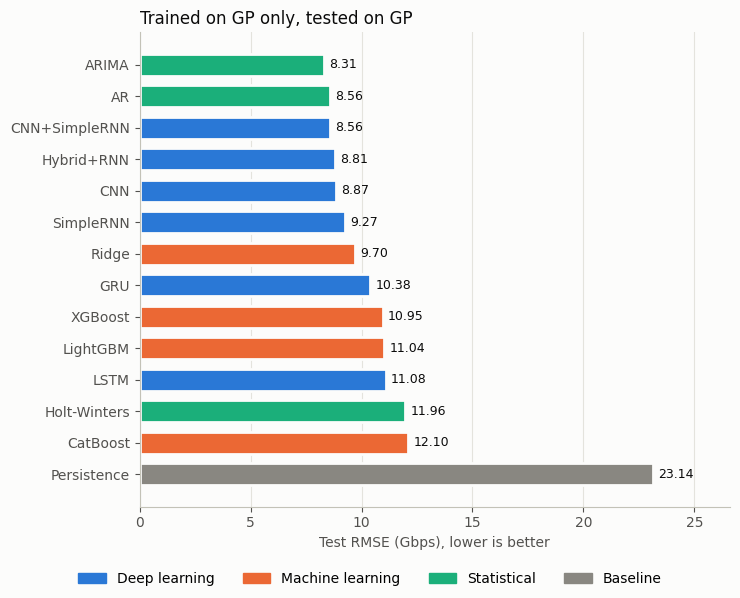

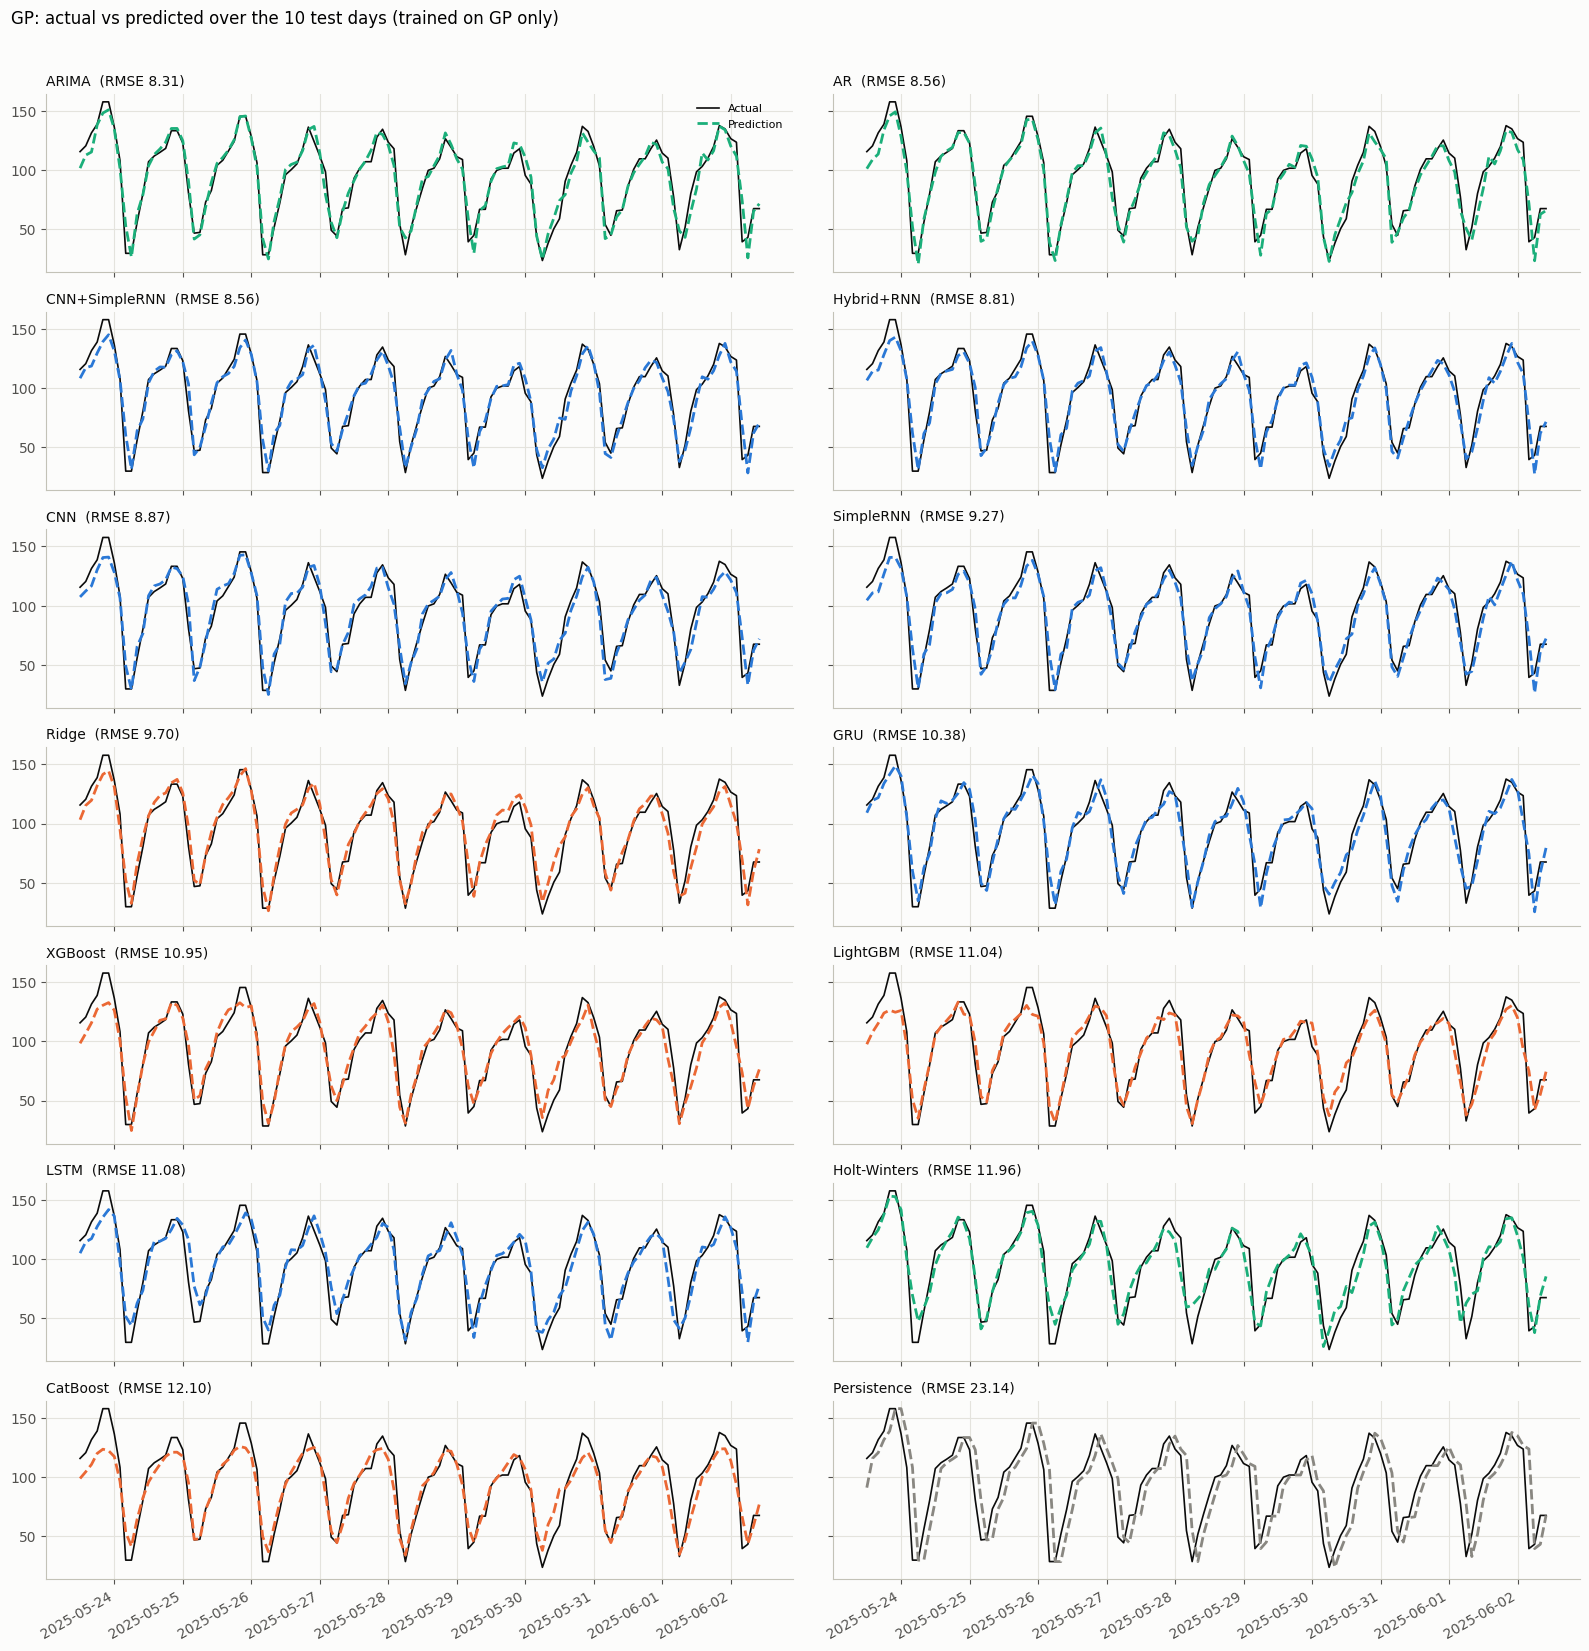

In [18]:
family_colors = {'Deep learning': '#2a78d6', 'Machine learning': '#eb6834',
                 'Statistical': '#1baf7a', 'Baseline': '#898781'}
plt.rcParams.update({'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb', 'axes.edgecolor': '#c3c2b7',
                     'axes.labelcolor': '#52514e', 'xtick.color': '#52514e', 'ytick.color': '#52514e',
                     'axes.spines.top': False, 'axes.spines.right': False})

fig, axes = plt.subplots(1, len(operators), figsize=(7.5 * len(operators), 6), squeeze=False)
for ax, operator in zip(axes[0], operators):
    part = test_metrics[test_metrics.operator.eq(operator)].sort_values('RMSE_Gbps')
    colors = [family_colors[f] for f in part.family]
    ax.barh(part.model, part.RMSE_Gbps, color=colors, height=0.7, edgecolor='#fcfcfb', linewidth=2)
    ax.invert_yaxis()
    for i, value in enumerate(part.RMSE_Gbps):
        ax.text(value + part.RMSE_Gbps.max() * 0.01, i, f'{value:.2f}', va='center', color='#0b0b0b', fontsize=9)
    ax.set_xlim(0, part.RMSE_Gbps.max() * 1.15)
    ax.set_xlabel('Test RMSE (Gbps), lower is better')
    ax.set_title(f'Trained on {train_label}, tested on {operator}', color='#0b0b0b', loc='left')
    ax.grid(axis='x', color='#e4e3dd', linewidth=0.8)
    ax.set_axisbelow(True)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in family_colors.values()]
fig.legend(handles, family_colors.keys(), loc='lower center', ncol=4, frameon=False)
fig.tight_layout(rect=(0, 0.05, 1, 1))
fig.savefig(output_dir / 'test_RMSE_by_model.png', dpi=150)
plt.show()

for operator in operators:
    part = test_predictions[test_predictions.operator.eq(operator)]
    ranked = test_metrics[test_metrics.operator.eq(operator)].set_index('model').RMSE_Gbps
    names = ranked.sort_values().index.tolist()
    rows_needed = int(np.ceil(len(names) / 2))
    fig, axes = plt.subplots(rows_needed, 2, figsize=(16, 2.4 * rows_needed), sharex=True, sharey=True)
    for ax, name in zip(axes.ravel(), names):
        one = part[part.model.eq(name)].sort_values('Timestamp')
        ax.plot(one.Timestamp, one.actual_Gbps, color='#0b0b0b', linewidth=1.2, label='Actual')
        ax.plot(one.Timestamp, one.predicted_Gbps, color=family_colors[family[name]], linewidth=2,
                linestyle='--', label='Prediction')
        ax.set_title(f'{name}  (RMSE {ranked[name]:.2f})', fontsize=10, loc='left', color='#0b0b0b')
        ax.grid(color='#e4e3dd', linewidth=0.8)
    for ax in axes.ravel()[len(names):]:
        ax.axis('off')
    axes.ravel()[0].legend(loc='upper right', fontsize=8, frameon=False)
    fig.suptitle(f'{operator}: actual vs predicted over the 10 test days (trained on {train_label})', x=0.01, ha='left')
    fig.autofmt_xdate()
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    fig.savefig(output_dir / f'{operator}_test_forecasts.png', dpi=130)
    plt.show()

## 17. Forecast and capacity-allocation evaluation


In [19]:
slot_hours = float(interval / pd.Timedelta(hours=1))
assert slot_hours > 0
forecast_snapshot = test_predictions.copy(deep=True)
allocation_slot_frames, allocation_metric_rows, forecast_metric_rows = [], [], []

def conditional_mean(values):
    # No applicable slots is undefined, rather than a fabricated zero average.
    return float(np.mean(values)) if len(values) else np.nan

for key, group in test_predictions.groupby(['operator', 'model'], sort=True):
    group = group.sort_values('Timestamp').reset_index(drop=True)
    observed = group.actual_Gbps.to_numpy(dtype=float)
    forecast = group.predicted_Gbps.to_numpy(dtype=float)
    assert len(group) == 120
    assert np.isfinite(observed).all() and np.isfinite(forecast).all()
    assert (observed >= 0).all() and (group.Timestamp >= test_start).all()
    margin = allocation_margins[key]
    baseline_capacity = np.maximum(0.0, forecast)
    buffered_capacity = baseline_capacity + margin
    assert (buffered_capacity >= baseline_capacity).all()

    slots = group[['Timestamp', 'operator', 'model', 'actual_Gbps', 'predicted_Gbps']].copy()
    slots['baseline_capacity_Gbps'] = baseline_capacity
    slots['margin_Gbps'] = margin
    slots['allocated_capacity_Gbps'] = buffered_capacity
    low_offset, high_offset = diagnostic_band_offsets[key]
    slots['diagnostic_band_lower_Gbps'] = np.maximum(0.0, forecast + low_offset)
    slots['diagnostic_band_upper_Gbps'] = np.maximum(0.0, forecast + high_offset)

    for policy_name, capacity, prefix in [
        ('Forecast only', baseline_capacity, 'baseline'),
        ('With margin', buffered_capacity, 'buffered'),
    ]:
        gap = observed - capacity
        under, over, equal = gap > 0, gap < 0, gap == 0
        shortfall, excess = np.maximum(gap, 0), np.maximum(-gap, 0)
        assert int(under.sum() + over.sum() + equal.sum()) == len(group)
        slots[f'{prefix}_under'] = under
        slots[f'{prefix}_over'] = over
        slots[f'{prefix}_shortfall_Gbps'] = shortfall
        slots[f'{prefix}_excess_Gbps'] = excess
        allocation_metric_rows.append({
            'operator': key[0], 'model': key[1], 'policy': policy_name,
            'n': len(group), 'margin_Gbps': margin if prefix == 'buffered' else 0.0,
            'under_count': int(under.sum()), 'under_pct': float(under.mean() * 100),
            'over_count': int(over.sum()), 'over_pct': float(over.mean() * 100),
            'equal_count': int(equal.sum()), 'equal_pct': float(equal.mean() * 100),
            'avg_shortfall_when_under_Gbps': conditional_mean(shortfall[under]),
            'avg_excess_when_over_Gbps': conditional_mean(excess[over]),
            'total_shortfall_Gbps_h': float(shortfall.sum() * slot_hours),
            'total_excess_Gbps_h': float(excess.sum() * slot_hours),
            'mean_allocated_capacity_Gbps': float(capacity.mean()),
        })
    assert np.all(slots.buffered_shortfall_Gbps <= slots.baseline_shortfall_Gbps + 1e-9)
    assert np.all(slots.buffered_excess_Gbps + 1e-9 >= slots.baseline_excess_Gbps)
    allocation_slot_frames.append(slots)

    error = observed - forecast
    positive = observed > 0
    percentage_error = np.abs(error[positive]) / observed[positive] * 100
    centered_sum = float(np.sum((observed - observed.mean()) ** 2))
    lower = slots.diagnostic_band_lower_Gbps.to_numpy()
    upper = slots.diagnostic_band_upper_Gbps.to_numpy()
    forecast_metric_rows.append({
        'operator': key[0], 'model': key[1], 'n': len(group),
        'RMSE_Gbps': float(np.sqrt(np.mean(error ** 2))),
        'MAE_Gbps': float(np.mean(np.abs(error))),
        'MAPE_pct_positive_actual': conditional_mean(percentage_error),
        'percentage_metric_n': int(positive.sum()),
        'zero_actual_n': int((~positive).sum()),
        'R2': 1 - float(np.sum(error ** 2)) / centered_sum if centered_sum > 0 else np.nan,
        'within_tolerance_pct_positive_actual': (
            float(np.mean(percentage_error <= forecast_tolerance_pct) * 100)
            if len(percentage_error) else np.nan
        ),
        'forecast_underprediction_pct': float(np.mean(forecast < observed) * 100),
        'forecast_overprediction_pct': float(np.mean(forecast > observed) * 100),
        'negative_forecast_n': int(np.sum(forecast < 0)),
        'nominal_band_pct': diagnostic_band_level * 100,
        'observed_band_coverage_pct': float(np.mean((observed >= lower) & (observed <= upper)) * 100),
        'avg_band_width_Gbps': float(np.mean(upper - lower)),
    })

allocation_predictions = pd.concat(allocation_slot_frames, ignore_index=True)
allocation_metrics = pd.DataFrame(allocation_metric_rows)
forecast_diagnostics = pd.DataFrame(forecast_metric_rows)
pd.testing.assert_frame_equal(test_predictions, forecast_snapshot)
assert not allocation_predictions.duplicated(['Timestamp', 'operator', 'model']).any()
np.testing.assert_allclose(
    forecast_diagnostics.set_index(['operator', 'model']).RMSE_Gbps.sort_index(),
    test_metrics.set_index(['operator', 'model']).RMSE_Gbps.sort_index(),
)

allocation_comparisons = {}
for operator in operators:
    forecast_table = forecast_diagnostics[forecast_diagnostics.operator.eq(operator)].sort_values('RMSE_Gbps')
    order = forecast_table.model.tolist()
    own_metrics = allocation_metrics[allocation_metrics.operator.eq(operator)]
    before = own_metrics[own_metrics.policy.eq('Forecast only')].set_index('model').loc[order]
    after = own_metrics[own_metrics.policy.eq('With margin')].set_index('model').loc[order]
    comparison = pd.DataFrame({
        'Margin (Gbps)': after.margin_Gbps,
        'Under before (%)': before.under_pct,
        'Under after (%)': after.under_pct,
        'Shortfall before (Gbps·h)': before.total_shortfall_Gbps_h,
        'Shortfall after (Gbps·h)': after.total_shortfall_Gbps_h,
        'Excess before (Gbps·h)': before.total_excess_Gbps_h,
        'Excess after (Gbps·h)': after.total_excess_Gbps_h,
    })
    allocation_comparisons[operator] = comparison
    print(f'{operator}: unchanged forecast errors on 120 historical holdout slots')
    display(forecast_table.set_index('model')[
        ['RMSE_Gbps', 'MAE_Gbps', 'MAPE_pct_positive_actual', 'percentage_metric_n',
         'R2', 'observed_band_coverage_pct']
    ].round(3))
    print(f'{operator}: simulated capacity, forecast only versus frozen validation margin')
    display(comparison.round(3))

allocation_predictions.to_csv(output_dir / 'allocation_predictions.csv', index=False)
allocation_metrics.to_csv(output_dir / 'allocation_metrics.csv', index=False)
forecast_diagnostics.to_csv(output_dir / 'forecast_diagnostics.csv', index=False)
for operator, table in allocation_comparisons.items():
    table.to_csv(output_dir / f'{operator}_allocation_comparison.csv')


GP: unchanged forecast errors on 120 historical holdout slots
GP: simulated capacity, forecast only versus frozen validation margin


,RMSE_Gbps,MAE_Gbps,MAPE_pct_positive_actual,percentage_metric_n,R2,observed_band_coverage_pct
model,,,,,,
ARIMA,8.312,6.044,9.159,120,0.938,84.167
AR,8.559,6.407,9.518,120,0.934,85.833
CNN+SimpleRNN,8.563,6.313,9.481,120,0.934,86.667
Hybrid+RNN,8.809,6.518,9.818,120,0.930,89.167
CNN,8.871,6.928,9.997,120,0.929,88.333
SimpleRNN,9.266,6.929,10.347,120,0.923,88.333
Ridge,9.696,7.533,10.734,120,0.915,86.667
GRU,10.385,7.935,11.874,120,0.903,87.500
XGBoost,10.952,8.051,11.004,120,0.892,85.833


,Margin (Gbps),Under before (%),Under after (%),Shortfall before (Gbps·h),Shortfall after (Gbps·h),Excess before (Gbps·h),Excess after (Gbps·h)
model,,,,,,,
ARIMA,13.862,50.833,6.667,723.497,30.388,727.175,3360.936
AR,12.723,64.167,8.333,1008.042,82.041,529.632,2657.114
CNN+SimpleRNN,16.627,54.167,1.667,795.330,4.860,719.686,3919.644
Hybrid+RNN,15.882,58.333,2.500,894.861,4.579,669.555,3591.009
CNN,14.659,49.167,6.667,823.580,22.586,839.044,3556.149
SimpleRNN,14.254,63.333,5.833,1018.921,27.215,643.954,3073.324
Ridge,16.154,45.000,5.000,773.060,33.232,1034.860,4171.911
GRU,16.148,52.500,5.833,981.169,39.502,923.113,3856.948
XGBoost,19.246,51.667,5.000,1044.250,78.433,887.948,4541.225


### Allocation trade-off charts


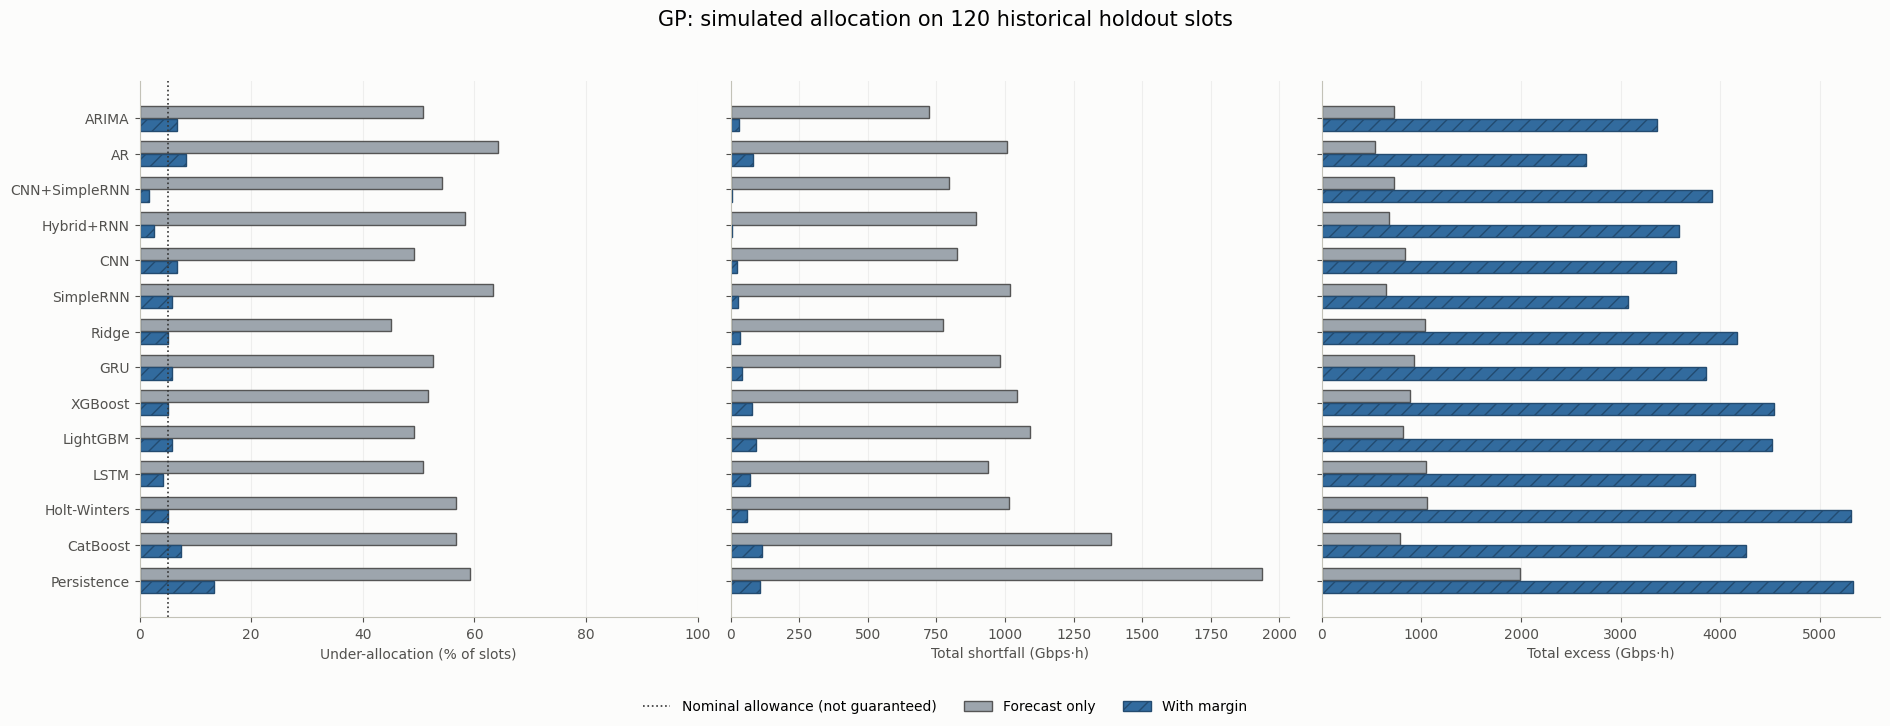

In [20]:
allocation_plot_paths = []
for operator in operators:
    own = allocation_metrics[allocation_metrics.operator.eq(operator)]
    order = allocation_comparisons[operator].index.tolist()
    before = own[own.policy.eq('Forecast only')].set_index('model').loc[order]
    after = own[own.policy.eq('With margin')].set_index('model').loc[order]
    positions = np.arange(len(order))
    fig, axes = plt.subplots(1, 3, figsize=(19, max(7, len(order) * 0.52)), sharey=True)
    specs = [
        ('under_pct', 'Under-allocation (% of slots)'),
        ('total_shortfall_Gbps_h', 'Total shortfall (Gbps·h)'),
        ('total_excess_Gbps_h', 'Total excess (Gbps·h)'),
    ]
    for ax, (metric, label) in zip(axes, specs):
        ax.barh(positions - 0.18, before[metric], height=0.34,
                color='#9da5ad', edgecolor='#555555', label='Forecast only')
        ax.barh(positions + 0.18, after[metric], height=0.34,
                color='#326b9e', edgecolor='#234b70', hatch='//', label='With margin')
        ax.set_xlabel(label)
        ax.set_xlim(left=0)
        ax.set_yticks(positions)
        ax.grid(axis='x', alpha=0.18)
        ax.set_axisbelow(True)
    axes[0].set_yticklabels(order)
    axes[0].invert_yaxis()
    axes[0].set_xlim(0, 100)
    axes[0].axvline((1 - allocation_policy_config['quantile']) * 100,
                    color='#333333', linestyle=':', linewidth=1.2,
                    label='Nominal allowance (not guaranteed)')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False)
    fig.suptitle(f'{operator}: simulated allocation on 120 historical holdout slots', fontsize=15)
    fig.tight_layout(rect=[0, 0.065, 1, 0.95])
    plot_path = output_dir / f'{operator}_allocation_tradeoff.png'
    fig.savefig(plot_path, dpi=150, bbox_inches='tight')
    allocation_plot_paths.append(plot_path)
    plt.show()
    plt.close(fig)


## 18. Save all results and create the ZIP


In [21]:
validation_for_allocation.to_csv(output_dir / 'validation_predictions.csv', index=False)
test_predictions.to_csv(output_dir / 'test_predictions.csv', index=False)
train_predictions.to_csv(output_dir / 'train_predictions.csv', index=False)
test_metrics.to_csv(output_dir / 'test_metrics.csv', index=False)
validation_metrics.to_csv(output_dir / 'validation_metrics.csv', index=False)
fit_check.to_csv(output_dir / 'train_validation_test_rmse.csv', index=False)
seed_results.to_csv(output_dir / 'neural_seed_results.csv', index=False)
same_data.to_csv(output_dir / 'data_split.csv', index=False)
summary.to_csv(output_dir / 'summary.csv')

versions = {}
for package in ['numpy', 'pandas', 'scikit-learn', 'lightgbm', 'xgboost', 'catboost', 'statsmodels']:
    try:
        versions[package] = version(package)
    except Exception:
        versions[package] = 'unknown'
versions['tensorflow'] = tf.__version__
manifest = {'source_workbook_sha256': {op: EMBEDDED_WORKBOOKS[op]['sha256'] for op in operators}, 'mode': mode, 'operators': operators, 'sources': sources,
            'validation_start': str(valid_start), 'test_start': str(test_start),
            'rows_per_operator': {'train': int((train_mask & meta.operator.eq(operators[0]).to_numpy()).sum()),
                                  'validation': 120, 'test': 120},
            'lags': lags, 'rolling_windows': roll_windows, 'lookback': lookback, 'features': feature_names,
            'seeds': seeds, 'tuning_seeds': tuning_seeds, 'max_epochs': max_epochs, 'patience': patience,
            'selected_settings': selected, 'target_scalers': target_scalers, 'versions': versions}
(output_dir / 'run_manifest.json').write_text(json.dumps(manifest, indent=2, default=str))


manifest['allocation_policy'] = allocation_policy_config
manifest['allocation_policy_sha256'] = allocation_policy_sha256
manifest['allocation_calibration'] = allocation_policy_records
manifest['execution_note'] = 'Metrics in this folder are produced by this execution.'
manifest['statistical_reference_sources'] = globals().get('statistical_reference_sources', {})
(output_dir / 'run_manifest.json').write_text(json.dumps(manifest, indent=2, default=str))

# Archive only outputs produced by this run, after allocation tables and charts.
export_names = [
    'test_predictions.csv', 'train_predictions.csv', 'test_metrics.csv',
    'validation_predictions.csv', 'validation_metrics.csv', 'train_validation_test_rmse.csv',
    'neural_seed_results.csv', 'data_split.csv', 'summary.csv',
    'tuning_results.csv', 'selected_settings.json', 'run_manifest.json',
    'test_RMSE_by_model.png', 'allocation_calibration.csv', 'allocation_policy.json',
    'allocation_predictions.csv', 'allocation_metrics.csv', 'forecast_diagnostics.csv',
]
for operator in operators:
    export_names += [f'{operator}_test_forecasts.png',
                     f'{operator}_allocation_comparison.csv',
                     f'{operator}_allocation_tradeoff.png']
if mode == 'Combined' and len(comparison_rows) > 0:
    export_names.append('single_vs_ensembled.csv')
archive = output_root / f'{run_name}_results.zip'
with zipfile.ZipFile(archive, 'w', zipfile.ZIP_DEFLATED) as z:
    for name in export_names:
        path = output_dir / name
        assert path.is_file(), f'Missing current-run export: {path}'
        z.write(path, path.name)
print('Saved forecasts and allocation results to', output_dir)
print('Download everything as one file:', archive)


Saved forecasts and allocation results to /workspace/scratch/4e80f3c50d8c/run/final_model_results/GP_only
Download everything as one file: /workspace/scratch/4e80f3c50d8c/run/final_model_results/GP_only_results.zip
